In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import io
from model import TabTransformer, ImprovedTabTransformer
from torch.optim import AdamW

# Model Development & Evalaution

In this notebook, we:

1. Train the model

2. Evaluate the model performance, generate report and plots

3. Evaluate and compare with the baseline model (Simple MLP)

4. Predict K bundle of portfolios

5. Produce Couple pattern compatability score

## Load Proprocessed Data

#### Demographic Features included:

  - **Gender**: 'first_partner_gender', 'second_partner_gender'
  - **Age Group**: 'second_partner_gender', 'second_partner_gender'
  - **Undegraduate School Type**: 'first_partner_school_category', 'second_partner_school_category'
  - **Job Level**: 'first_partner_level_id', 'second_partner_level_id'
  - **Job Field**: 'first_partner_field',  'second_partner_field'
  - **If Attend Graduate School**: 'first_partner_is_graduate', 'second_partner_is_graduate'
  - **How first met**: 'how_first_met_category'

In [2]:
# --- 1. Load Data ---
## df = pd.read_excel("../data/data_demo.xlsx")
df_orig = pd.read_excel("../data/data_final_revision.xlsx")

In [3]:
df_orig.columns

Index(['url', 'filename', 'first_partner_gender', 'first_partner_age_bin',
       'second_partner_gender', 'second_partner_age_bin',
       'first_partner_school_category', 'second_partner_school_category',
       'first_partner_level_id', 'second_partner_level_id',
       'first_partner_field', 'second_partner_field', 'how_first_met_category',
       'first_partner_is_graduate', 'second_partner_is_graduate'],
      dtype='object')

In [4]:
df_orig.head(3)

,url,filename,first_partner_gender,first_partner_age_bin,second_partner_gender,second_partner_age_bin,first_partner_school_category,second_partner_school_category,first_partner_level_id,second_partner_level_id,first_partner_field,second_partner_field,how_first_met_category,first_partner_is_graduate,second_partner_is_graduate
0,https://www.nytimes.com/2015/01/11/fashion/wed...,f657c24a-6a56-5ca4-b97f-088c31f8e0bb,Female,30-34,Male,30-34,Top 50 Private (Non-Ivy),Top 50 Private (Non-Ivy),S4,NaN,Architecture and Engineering Occupations,NaN,Work or School,1,1
1,https://www.nytimes.com/2015/08/02/fashion/wed...,def8fbc6-6199-520e-be42-42ecf6f1a26b,Female,30-34,Unknown,30-34,Ivy League,Ivy League,S5,S5,Management Occupations,Architecture and Engineering Occupations,Work or School,1,1
2,https://www.nytimes.com/2015/06/14/fashion/wed...,1e99518c-5fe6-59a2-a4a6-9b9d91afcf3b,Female,25-29,Male,35-39,Other Colleges,Top 50 Private (Non-Ivy),S4,S5,Healthcare Occupations,Healthcare Occupations,Other,1,1


## Encode categorical features

In [6]:
'''
this ensure that both first mentioned partner(male usually) and the second mentioned partner(female usually) are both used as the input and output, thus reduct traning df bais
''' 

df_A2B = df_orig.rename(columns={
    'first_partner_gender': 'partner_gender',
    'first_partner_age_bin': 'partner_age_bin',
    'first_partner_school_category': 'partner_school_category',
    'first_partner_level_id': 'partner_level_id',
    'first_partner_field': 'partner_field',
    'first_partner_is_graduate': 'partner_is_graduate',
    'second_partner_gender': 'target_gender',
    'second_partner_age_bin': 'target_age_bin',
    'second_partner_school_category': 'target_school_category',
    'second_partner_level_id': 'target_level_id',
    'second_partner_field': 'target_field'
})

df_B2A = df_orig.rename(columns={
    'second_partner_gender': 'partner_gender',
    'second_partner_age_bin': 'partner_age_bin',
    'second_partner_school_category': 'partner_school_category',
    'second_partner_level_id': 'partner_level_id',
    'second_partner_field': 'partner_field',
    'second_partner_is_graduate': 'partner_is_graduate',
    'first_partner_gender': 'target_gender',
    'first_partner_age_bin': 'target_age_bin',
    'first_partner_school_category': 'target_school_category',
    'first_partner_level_id': 'target_level_id',
    'first_partner_field': 'target_field'
})

df = pd.concat([df_A2B, df_B2A], ignore_index=True)

In [7]:
input_cols = ['partner_gender', 'partner_age_bin', 'partner_school_category',
              'partner_level_id', 'partner_field', 'partner_is_graduate']
output_cols = ['target_gender', 'target_age_bin', 'target_school_category',
               'target_level_id', 'target_field']
columns_to_encode = input_cols + output_cols

label_encoders = {}
gender_classes = ['Male', 'Female', 'Nonbinary', 'Unknown']

# First create and fit a gender encoder
gender_le = LabelEncoder()
gender_le.fit(gender_classes)  # This is the critical step we were missing before 

for col in columns_to_encode:
    df[col] = df[col].replace('Not mentioned', 'Unknown').astype(str).str.strip()
    
    if col in ['partner_gender', 'target_gender']:
        df[col] = df[col].apply(lambda x: x if x in gender_classes else 'Unknown')
        df[col] = gender_le.transform(df[col])
        label_encoders[col] = gender_le
    else:
        # Regular encoding for non-gender columns
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    
    # Check for class imbalance - now showing actual distribution
    class_counts = df[col].value_counts(normalize=True)
    print(f"\nClass distribution for {col}:")
    
    if col in ['partner_gender', 'target_gender']:
        # For gender columns, show human-readable labels
        for class_idx, percent in class_counts.items():
            print(f"  {gender_classes[class_idx]}: {percent*100:.1f}%")
    else:
        # For other columns, just show the encoded values
        print(class_counts.to_string())
    
    if len(class_counts) > 0 and class_counts.iloc[0] > 0.8:
        if col in ['partner_gender', 'target_gender']:
            dominant_class = gender_classes[class_counts.index[0]]
        else:
            dominant_class = class_counts.index[0]
        print(f"Warning: Dominant class '{dominant_class}' has {class_counts.iloc[0]*100:.1f}% of data")


Class distribution for partner_gender:
  Female: 47.0%
  Male: 45.8%
  Unknown: 7.1%
  Nonbinary: 0.0%

Class distribution for partner_age_bin:
partner_age_bin
1    0.395763
0    0.308726
2    0.127007
4    0.125478
3    0.043027

Class distribution for partner_school_category:
partner_school_category
2    0.452932
4    0.211368
0    0.205690
1    0.084799
3    0.045211

Class distribution for partner_level_id:
partner_level_id
3    0.405373
4    0.314841
2    0.155728
0    0.063886
6    0.037785
1    0.011467
5    0.010921

Class distribution for partner_field:
partner_field
3     0.286065
14    0.118980
12    0.099214
16    0.073659
18    0.070001
7     0.068527
1     0.055695
4     0.040297
26    0.037785
5     0.029977
0     0.027083
24    0.020749
15    0.019166
20    0.017855
8     0.014961
19    0.005570
11    0.003331
21    0.001857
23    0.001747
13    0.001474
6     0.001365
22    0.001256
25    0.000928
2     0.000819
17    0.000819
10    0.000601
9     0.000218

Class dist

## Split Data

In [8]:
# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    df[input_cols].values,
    df[output_cols].values,
    test_size=0.2, # 20% used for testing 
    random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [9]:
def augment_batch(batch_X, mask_prob=0.15, unknown_token=0):
    """Enhanced data augmentation with smarter masking"""
    # Create mask for random elements
    mask = torch.rand_like(batch_X.float()) < mask_prob
    
    # Create augmented batch by replacing masked elements with unknown token
    augmented = torch.where(mask, unknown_token * torch.ones_like(batch_X), batch_X)
    
    return augmented

## Train and Test

In [10]:
# initialize 
input_cardinality = [df[col].nunique() for col in input_cols]
output_cardinality = [df[col].nunique() for col in output_cols]

# model
model = ImprovedTabTransformer(
    category_sizes=input_cardinality,
    dim=64,  
    output_sizes=output_cardinality
)

In [11]:
# --- Train ---
criterions = [nn.CrossEntropyLoss() for _ in output_cols]
# optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer = optim.AdamW(model.parameters(), lr=0.001)


def augment_batch(batch_X, mask_prob=0.2):
    mask = torch.rand_like(batch_X.float()) < mask_prob
    # Replace with "unknown" token (assuming 0 is unused/unknown)
    return torch.where(mask, torch.zeros_like(batch_X), batch_X)


def train(model, X, Y, epochs=10, batch_size=64):
    model.train()
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        permutation = torch.randperm(X.size()[0])
        total_loss = 0

        for i in range(0, X.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            batch_X, batch_Y = X[indices], Y[indices]
            batch_X = augment_batch(batch_X)

            optimizer.zero_grad()
            outputs = model(batch_X)

            losses = [
                criterions[j](outputs[j], batch_Y[:, j])
                for j in range(len(output_cols))
            ]
            loss = sum(losses)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f'Epoch {epoch+1}, Loss: {total_loss / len(X)}')
        
train(model, X_train, Y_train)

Epoch 1/10
Epoch 1, Loss: 0.11325302404573319
Epoch 2/10
Epoch 2, Loss: 0.10661252494818782
Epoch 3/10
Epoch 3, Loss: 0.10549596219931469
Epoch 4/10
Epoch 4, Loss: 0.10486372185521513
Epoch 5/10
Epoch 5, Loss: 0.10454081769738456
Epoch 6/10
Epoch 6, Loss: 0.10411567536973032
Epoch 7/10
Epoch 7, Loss: 0.10387298130157514
Epoch 8/10
Epoch 8, Loss: 0.10361656395048585
Epoch 9/10
Epoch 9, Loss: 0.10325006240627056
Epoch 10/10
Epoch 10, Loss: 0.10324861077218891


In [15]:
def evaluate(model, X, Y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        total_acc = 0
        feature_acc = []
        preds = []

        for j in range(len(output_cols)):
            _, predicted = torch.max(outputs[j].data, 1)
            preds.append(predicted)
            correct = (predicted == Y[:, j]).sum().item()
            acc = correct / Y.size(0)
            feature_acc.append(acc)
            total_acc += acc

        avg_acc = total_acc / len(output_cols)

        # --- Per-row average accuracy (soft exact match) ---
        # pred_stack: [num_outputs, batch_size] -> transpose to [batch_size, num_outputs]
        pred_stack = torch.stack(preds).T
        correct_matrix = (pred_stack == Y)  # [batch_size, num_outputs]
        rowwise_accuracy = correct_matrix.float().mean(dim=1)  # accuracy for each individual
        soft_exact_match_acc = rowwise_accuracy.mean().item()  # average across individuals

        print(f'Average Accuracy (per output column): {avg_acc:.4f}')
        print(f'Average Per-Row Accuracy (soft exact match): {soft_exact_match_acc:.4f}')
        for col, acc in zip(output_cols, feature_acc):
            print(f'{col}: {acc:.4f}')

evaluate(model, X_test, Y_test)


Average Accuracy (per output column): 0.5542
Average Per-Row Accuracy (soft exact match): 0.5542
target_gender: 0.8346
target_age_bin: 0.6306
target_school_category: 0.4966
target_level_id: 0.4521
target_field: 0.3574


In [16]:
from sklearn.metrics import classification_report

def detailed_evaluate(model, X, Y, label_encoders, output_path="../result/evaluation_report.txt"):
    model.eval()
    report_output = io.StringIO()
    
    with torch.no_grad():
        outputs = model(X)
        
        for j, col in enumerate(output_cols):
            _, preds = torch.max(outputs[j], 1)
            true = Y[:, j]
            
            le = label_encoders[col]
            if col in ['target_gender', 'partner_gender']:
                target_names = gender_classes
            else:
                target_names = le.classes_

            report_output.write(f"\nEvaluation for {col}:\n")
            report_output.write(
                classification_report(
                    true.numpy(),
                    preds.numpy(),
                    target_names=target_names,
                    zero_division=0
                )
            )
    
    # Save to txt file
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(report_output.getvalue())

    print(f"Evaluation results saved to {output_path}")

detailed_evaluate(model, X_test, Y_test, label_encoders)

Evaluation results saved to ../result/evaluation_report.txt


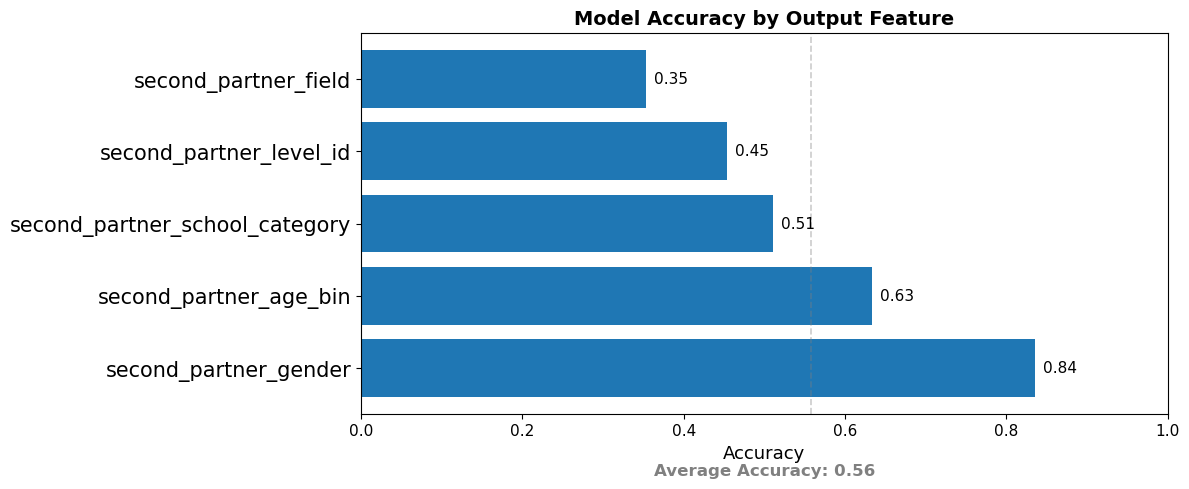

In [17]:
output_fields = [
    "second_partner_gender",
    "second_partner_age_bin",
    "second_partner_school_category",
    "second_partner_level_id",
    "second_partner_field",
]
accuracies = [0.8354, 0.6331, 0.5111, 0.4535, 0.3527]
avg_accuracy = sum(accuracies) / len(accuracies)

plt.figure(figsize=(12, 5))
bars = plt.barh(output_fields, accuracies, color='#1f77b4')  
plt.xlabel("Accuracy", fontsize=13)
plt.title("Model Accuracy by Output Feature", fontsize=14, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=15)
plt.xlim(0, 1)

for bar, acc in zip(bars, accuracies):
    plt.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
             f"{acc:.2f}", va='center', fontsize=11)

plt.axvline(x=avg_accuracy, color='gray', linestyle='--', linewidth=1.2, alpha=0.4)

plt.text(0.5, -0.15, f"Average Accuracy: {avg_accuracy:.2f}",
         ha='center', va='center', transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', color='gray')

plt.tight_layout()
plt.savefig("../result/model_accuracy_by_output_feature.png", dpi=300)
plt.show()

## Sample Test

This is our base goal: Train a TabTransformer that, given a person’s demographic profile (e.g., gender, race, education, occupation), predicts ideal partner's attributes (e.g., partner's age range, education level, region, etc.). 

In [18]:
def predict_partner(sample_row, model, label_encoders):
    """
    Predict partner attributes from a sample input row (6 features)

    Args:
        sample_row: List of [gender, age_bin, school_category, level_id, field, is_graduate]
        model: Trained TabTransformer model
        label_encoders: Dictionary of fitted LabelEncoders

    Returns:
        Dictionary of predicted attributes
    """
    model.eval()

    expected_len = 6
    
    if len(sample_row) != expected_len:
        raise ValueError(f"Input row must contain {expected_len} features: [gender, age_bin, school_category, level_id, field, is_graduate]")

    input_cols = [
        'partner_gender',
        'partner_age_bin',
        'partner_school_category',
        'partner_level_id',
        'partner_field',
        'partner_is_graduate'
    ]


    try:
        encoded_sample = []
        for col, value in zip(input_cols, sample_row):
            value_str = str(value).strip() if value is not None else 'Unknown'

            if value_str not in label_encoders[col].classes_:
                default_value = label_encoders[col].classes_[0]
                print(f"Warning: Unknown value '{value_str}' for {col}, using '{default_value}' instead")
                value_str = default_value

            encoded_val = label_encoders[col].transform([value_str])[0]
            encoded_sample.append(encoded_val)

    except Exception as e:
        print(f"Encoding error: {e}")
        return None

    sample_tensor = torch.tensor([encoded_sample], dtype=torch.long)

    with torch.no_grad():
        output_preds = model(sample_tensor)

    output_cols = [
        'target_gender',
        'target_age_bin',
        'target_school_category',
        'target_level_id',
        'target_field'
    ]

    predictions = {}
    for i, col in enumerate(output_cols):
        pred_class = torch.argmax(output_preds[i], dim=1).item()
        predictions[col] = label_encoders[col].inverse_transform([pred_class])[0]

    return predictions

#### Sample 1

In [19]:
sample_row = [
    'Female',                       # partner_gender
    '30-34',                        # partner_age_bin
    'Ivy League',                   # partner_school_category
    'S4',                           # partner_level_id
    'Computer and Information Technology Occupations',  # partner_field
    '1'                             # partner_is_graduate (as string to match encoder)
]

predictions = predict_partner(sample_row, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"Undergrad Category: {predictions['target_school_category']}")
    print(f"Job Level: {predictions['target_level_id']}")
    print(f"Field of Work:  {predictions['target_field']}")



=== Predicted Partner Profile ===
Gender:         Male
Age Group:      30-34
Undergrad Category: Other Colleges
Job Level: S4
Field of Work:  Business and Financial Occupations


#### Sample 2

In [20]:
sample_row_2 = [
    'Male',
    '25-29',
    'Top 50 Private (Non-Ivy)',
    'S3',
    'Architecture and Engineering Occupations',
    '0'  # not graduate
]

predictions = predict_partner(sample_row_2, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"Undergrad Category: {predictions['target_school_category']}")
    print(f"Job Level: {predictions['target_level_id']}")
    print(f"Field of Work:  {predictions['target_field']}")


=== Predicted Partner Profile ===
Gender:         Female
Age Group:      25-29
Undergrad Category: Top 50 Private (Non-Ivy)
Job Level: S4
Field of Work:  Business and Financial Occupations


#### Sample 3

In [21]:
sample_row_3 = [
    'Female',
    '35-39',
    'Top 50 Private (Non-Ivy)',
    'S5',
    'Arts and Design Occupations',
    '1'
]

predictions = predict_partner(sample_row_3, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"Undergrad Category: {predictions['target_school_category']}")
    print(f"Job Level: {predictions['target_level_id']}")
    print(f"Field of Work:  {predictions['target_field']}")


=== Predicted Partner Profile ===
Gender:         Male
Age Group:      35-39
Undergrad Category: Other Colleges
Job Level: S5
Field of Work:  Business and Financial Occupations


#### Sample 4

In [22]:
sample_row_4 = [
    'Nonbinary',
    '30-34',
    'Other Colleges',
    'S5',
    'Media and Communication Occupations',
    '1'
]

predictions = predict_partner(sample_row_4, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"Undergrad Category: {predictions['target_school_category']}")
    print(f"Job Level: {predictions['target_level_id']}")
    print(f"Field of Work:  {predictions['target_field']}")


=== Predicted Partner Profile ===
Gender:         Female
Age Group:      30-34
Undergrad Category: Other Colleges
Job Level: S4
Field of Work:  Media and Communication Occupations


## Predict k bundles of future partner attributes
This is our target goal: Extend the model to output the top 3 or top 10 most likely bundles of ideal partner characteristics.
This will allow us to evaluate prediction diversity and simulate more realistic matchmaking scenarios.

In [23]:
def predict_partner_bundles(sample_row, model, label_encoders, k=3):
    """
    Predict top k most likely bundles of partner attributes from a sample input row
    
    Args:
        sample_row: List of [gender, age_bin, school_category, level_id, field, is_graduate]
        model: Trained TabTransformer model
        label_encoders: Dictionary of fitted LabelEncoders
        k: Number of top predictions to return (default=3)
        
    Returns:
        List of dictionaries, each containing a bundle of predicted attributes with probabilities
    """
    model.eval()
    
    expected_len = 6
    
    if len(sample_row) != expected_len:
        raise ValueError(f"Input row must contain {expected_len} features: [gender, age_bin, school_category, level_id, field, is_graduate]")
    
    input_cols = [
        'partner_gender',
        'partner_age_bin',
        'partner_school_category',
        'partner_level_id',
        'partner_field',
        'partner_is_graduate'
    ]
    
    try:
        encoded_sample = []
        for col, value in zip(input_cols, sample_row):
            value_str = str(value).strip() if value is not None else 'Unknown'
            
            if value_str not in label_encoders[col].classes_:
                default_value = label_encoders[col].classes_[0]
                print(f"Warning: Unknown value '{value_str}' for {col}, using '{default_value}' instead")
                value_str = default_value
                
            encoded_val = label_encoders[col].transform([value_str])[0]
            encoded_sample.append(encoded_val)
            
    except Exception as e:
        print(f"Encoding error: {e}")
        return None
        
    sample_tensor = torch.tensor([encoded_sample], dtype=torch.long)
    
    with torch.no_grad():
        output_preds = model(sample_tensor)
    
    output_cols = [
        'target_gender',
        'target_age_bin',
        'target_school_category',
        'target_level_id',
        'target_field'
    ]
    
    softmax = nn.Softmax(dim=1)
    probs = [softmax(output) for output in output_preds]
    
    top_indices = []
    top_probs = []
    
    for i, prob in enumerate(probs):
        # Get top k values and indices
        values, indices = torch.topk(prob[0], k=min(k, len(label_encoders[output_cols[i]].classes_)))
        top_indices.append(indices.tolist())
        top_probs.append(values.tolist())
    
    bundles = []
    
    # Start with the most likely
    best_bundle = {
        output_cols[i]: label_encoders[output_cols[i]].inverse_transform([top_indices[i][0]])[0]
        for i in range(len(output_cols))
    }
    
    for i in range(len(output_cols)):
        best_bundle[f"{output_cols[i]}_prob"] = float(top_probs[i][0])
    
    best_bundle["bundle_probability"] = float(np.prod([top_probs[i][0] for i in range(len(output_cols))]))
    
    bundles.append(best_bundle)
    
    # Generate additional diverse bundles by varying the most uncertain predictions
    # Find the attributes with the most uncertainty (lowest top probability)
    uncertainty_ranking = sorted(range(len(output_cols)), key=lambda i: top_probs[i][0])
    
    # Generate additional bundles by varying the most uncertain attributes
    for bundle_idx in range(1, k):
        if bundle_idx >= len(uncertainty_ranking):
            break
            
        new_bundle = best_bundle.copy()
        
        # Vary the most uncertain attribute(s)
        for var_idx in range(min(bundle_idx, len(uncertainty_ranking))):
            attr_idx = uncertainty_ranking[var_idx]
            alt_pred_idx = min(bundle_idx, len(top_indices[attr_idx])-1)
            
            attr_name = output_cols[attr_idx]
            new_val = label_encoders[attr_name].inverse_transform([top_indices[attr_idx][alt_pred_idx]])[0]
            new_prob = float(top_probs[attr_idx][alt_pred_idx])
            
            new_bundle[attr_name] = new_val
            new_bundle[f"{attr_name}_prob"] = new_prob
        
        # Recalculate bundle probability
        new_bundle["bundle_probability"] = float(np.prod([
            new_bundle[f"{col}_prob"] for col in output_cols
        ]))
        
        bundles.append(new_bundle)
    
    # Sort bundles
    bundles.sort(key=lambda x: x["bundle_probability"], reverse=True)
    
    return bundles[:k]

### Bundle Sample

In [ ]:
# Sample input for prediction
sample_row = [
    'Female',                       # partner_gender
    '30-34',                        # partner_age_bin
    'Ivy League',                   # partner_school_category
    'S4',                           # partner_level_id
    'Entertainment and Sports Occupations',  # partner_field
    '1'                             # partner_is_graduate (as string to match encoder)
]

# Get top 3 prediction bundles
prediction_bundles = predict_top3_partner_bundles(sample_row, model, label_encoders, k=3)

# Display results
for i, bundle in enumerate(prediction_bundles):
    print(f"\n=== Bundle {i+1} (Probability: {bundle['bundle_probability']:.4f}) ===")
    print(f"Gender:          {bundle['target_gender']} ({bundle['target_gender_prob']:.2f})")
    print(f"Age Group:       {bundle['target_age_bin']} ({bundle['target_age_bin_prob']:.2f})")
    print(f"School Category: {bundle['target_school_category']} ({bundle['target_school_category_prob']:.2f})")
    print(f"Education Level: {bundle['target_level_id']} ({bundle['target_level_id_prob']:.2f})")
    print(f"Field of Study:  {bundle['target_field']} ({bundle['target_field_prob']:.2f})")


=== Bundle 1 (Probability: 0.0200) ===
Gender:          Male (0.76)
Age Group:       30-34 (0.64)
School Category: Other Colleges (0.47)
Education Level: S4 (0.46)
Field of Study:  Business and Financial Occupations (0.19)

=== Bundle 2 (Probability: 0.0176) ===
Gender:          Male (0.76)
Age Group:       30-34 (0.64)
School Category: Other Colleges (0.47)
Education Level: S4 (0.46)
Field of Study:  Arts and Design Occupations (0.17)

=== Bundle 3 (Probability: 0.0071) ===
Gender:          Male (0.76)
Age Group:       30-34 (0.64)
School Category: Other Colleges (0.47)
Education Level: S3 (0.20)
Field of Study:  Media and Communication Occupations (0.15)


: 

: 

## Compatibility Scoring Function
This is part of our stretch goal: Build an alternative prediction head or scoring logic that, given one person’s profile, assigns a compatibility score to 10 (or k)  candidate profiles.

This function calculates the compatibility score between two profiles based on their attributes.There is a custom weight for each attribute for the compatibility score.
The compatibility score is calculated by summing the absolute differences between the corresponding attributes of the two profiles. The score is then divided by the number of attributes to obtain an average difference per attribute.

In [ ]:
def compute_compatibility_scores(person_profile, candidate_profiles, model, label_encoders, weights=None):
    """
    Compute compatibility scores between one person's profile and multiple candidate profiles.
    
    Args:
        person_profile: List of [gender, age_bin, school_category, level_id, field, is_graduate]
        candidate_profiles: List of candidate profiles, each with the same format as person_profile
        model: Trained TabTransformer model
        label_encoders: Dictionary of fitted LabelEncoders
        weights: Optional dictionary of weights for each attribute {'gender': 0.2, 'age_bin': 0.2, ...}
                If None, equal weights will be used
    
    Returns:
        List of dictionaries containing candidate profiles with their compatibility scores
    """
    # Default weights if none provided
    if weights is None:
        weights = {
            'gender': 0.2,
            'age_bin': 0.2, 
            'school_category': 0.2,
            'level_id': 0.2,
            'field': 0.2
        }
    
    # Ensure weights sum to 1
    total_weight = sum(weights.values())
    normalized_weights = {k: v/total_weight for k, v in weights.items()}
    
    # Get predicted ideal partner for the person
    ideal_partner = predict_partner(person_profile, model, label_encoders)
    model.eval()
    
    input_cols = [
        'partner_gender',
        'partner_age_bin',
        'partner_school_category',
        'partner_level_id',
        'partner_field',
        'partner_is_graduate'
    ]
    
    output_cols = [
        'target_gender',
        'target_age_bin',
        'target_school_category',
        'target_level_id',
        'target_field'
    ]
    
    # Encode the input
    encoded_sample = []
    for col, value in zip(input_cols, person_profile):
        value_str = str(value).strip() if value is not None else 'Unknown'
        
        if value_str not in label_encoders[col].classes_:
            default_value = label_encoders[col].classes_[0]
            print(f"Warning: Unknown value '{value_str}' for {col}, using '{default_value}' instead")
            value_str = default_value
            
        encoded_val = label_encoders[col].transform([value_str])[0]
        encoded_sample.append(encoded_val)
    
    sample_tensor = torch.tensor([encoded_sample], dtype=torch.long)
    
    # Get model predictions (logits)
    with torch.no_grad():
        output_preds = model(sample_tensor)
    
    softmax = nn.Softmax(dim=1)
    probs = [softmax(output) for output in output_preds]
    
    results = []
    
    for i, candidate in enumerate(candidate_profiles):
        attribute_scores = {}
        
        # Calculate score for each attribute
        for j, attr in enumerate(output_cols):
            candidate_value = str(candidate[j]).strip() if candidate[j] is not None else 'Unknown'
            
            # Check if value exists in label encoder
            if candidate_value not in label_encoders[attr].classes_:
                default_value = label_encoders[attr].classes_[0]
                print(f"Warning: Unknown value '{candidate_value}' for {attr}, using '{default_value}' instead")
                candidate_value = default_value
        
            candidate_idx = label_encoders[attr].transform([candidate_value])[0]
            
            attr_prob = probs[j][0][candidate_idx].item()
            
            attr_name = attr.replace('target_', '')
            attribute_scores[attr_name] = attr_prob
        
        weighted_score = sum(attribute_scores[attr.replace('target_', '')] * normalized_weights[attr.replace('target_', '')] 
                            for attr in output_cols)
        
        result = {
            'candidate_id': i,
            'candidate_profile': {
                'gender': candidate[0],
                'age_bin': candidate[1],
                'school_category': candidate[2],
                'level_id': candidate[3],
                'field': candidate[4],
                'is_graduate': candidate[5]
            },
            'attribute_scores': attribute_scores,
            'compatibility_score': weighted_score,
            'match_percentage': weighted_score * 100  # Convert to percentage
        }
        
        results.append(result)

    results.sort(key=lambda x: x['compatibility_score'], reverse=True)
    
    return results

: 

: 

### Sample Compatibility Scoring Function

In [ ]:
# Person's profile
person_profile = [
    'Female',                       # partner_gender
    '30-34',                        # partner_age_bin
    'Ivy League',                   # partner_school_category
    'S4',                           # partner_level_id
    'Business and Financial Occupations',  # partner_field
    '1'                             # partner_is_graduate
]

# List of candidate profiles to score
candidate_profiles = [
    ['Male', '30-34', 'Ivy League', 'S4', 'Legal Occupations', '1'],
    ['Female', '30-34', 'Top 50 Private (Non-Ivy)', 'S4', 'Computer and Information Technology Occupations', '1'],
    ['Male', '25-29', 'Top 30 Public', 'S3', 'Educational Instruction and Library Occupations', '0'],
    # Add more candidate profiles as needed
]

# Optional: Custom weights for different attributes
custom_weights = {
    'gender': 0.3,      # Higher weight on gender
    'age_bin': 0.25,    # Higher weight on age
    'school_category': 0.2,
    'level_id': 0.15,
    'field': 0.1        # Lower weight on field
}

# Compute compatibility scores
results = compute_compatibility_scores(
    person_profile, 
    candidate_profiles, 
    model, 
    label_encoders,
    weights=custom_weights  # Optional
)

# Display results
print(f"Compatibility scores for {len(results)} candidates:")
for i, result in enumerate(results):
    print(f"\n=== Candidate {i+1}: {result['match_percentage']:.1f}% Match ===")
    print(f"Gender: {result['candidate_profile']['gender']} (Score: {result['attribute_scores']['gender']:.2f})")
    print(f"Age: {result['candidate_profile']['age_bin']} (Score: {result['attribute_scores']['age_bin']:.2f})")
    print(f"School: {result['candidate_profile']['school_category']} (Score: {result['attribute_scores']['school_category']:.2f})")
    print(f"Education: {result['candidate_profile']['level_id']} (Score: {result['attribute_scores']['level_id']:.2f})")
    print(f"Field: {result['candidate_profile']['field']} (Score: {result['attribute_scores']['field']:.2f})")

Compatibility scores for 3 candidates:

=== Candidate 1: 52.0% Match ===
Gender: Male (Score: 0.73)
Age: 30-34 (Score: 0.68)
School: Ivy League (Score: 0.28)
Education: S4 (Score: 0.43)
Field: Legal Occupations (Score: 0.12)

=== Candidate 2: 34.8% Match ===
Gender: Female (Score: 0.21)
Age: 30-34 (Score: 0.68)
School: Top 50 Private (Non-Ivy) (Score: 0.23)
Education: S4 (Score: 0.43)
Field: Computer and Information Technology Occupations (Score: 0.06)

=== Candidate 3: 28.6% Match ===
Gender: Male (Score: 0.73)
Age: 25-29 (Score: 0.14)
School: Top 30 Public (Score: 0.05)
Education: S3 (Score: 0.13)
Field: Educational Instruction and Library Occupations (Score: 0.05)


: 

: 

## Baseline Model

Compare with a simple MLP
  


In [ ]:
import torch.nn.functional as F
from collections import Counter

# 1. Define the baseline MLP
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_sizes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.output_heads = nn.ModuleList([
            nn.Linear(hidden_dim, out_size) for out_size in output_sizes
        ])

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return [head(x) for head in self.output_heads]

# 2. Helper for class weights
def compute_class_weights(y_col, num_classes):
    counts = Counter(y_col.tolist())
    total = sum(counts.values())
    weights = [total / (counts.get(i, 1)) for i in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float32)

# 3. Augment batch by masking
def augment_batch(batch_X, mask_prob=0.2):
    mask = torch.rand_like(batch_X.float()) < mask_prob
    return torch.where(mask, torch.zeros_like(batch_X), batch_X)

# 4. Training function
def train(model, X, Y, epochs=15, batch_size=64):
    model.train()
    for epoch in range(epochs):
        permutation = torch.randperm(X.size(0))
        total_loss = 0

        for i in range(0, X.size(0), batch_size):
            indices = permutation[i:i+batch_size]
            batch_X, batch_Y = X[indices].to(device).float(), Y[indices].to(device)

            batch_X = augment_batch(batch_X)

            optimizer.zero_grad()
            outputs = model(batch_X)

            losses = [
                criterions[j](outputs[j], batch_Y[:, j])
                for j in range(len(output_cols))
            ]
            loss = sum(losses)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f'Epoch {epoch+1}, Loss: {total_loss / len(X):.4f}')

# 5. Evaluation function
def evaluate(model, X, Y):
    model.eval()
    with torch.no_grad():
        X = X.to(device).float()
        Y = Y.to(device)
        outputs = model(X)
        total_acc = 0
        feature_acc = []

        for j in range(len(output_cols)):
            _, predicted = torch.max(outputs[j].data, 1)
            correct = (predicted == Y[:, j]).sum().item()
            acc = correct / Y.size(0)
            feature_acc.append(acc)
            total_acc += acc

        avg_acc = total_acc / len(output_cols)
        print(f'\nAverage Accuracy: {avg_acc:.4f}')
        for col, acc in zip(output_cols, feature_acc):
            print(f'{col}: {acc:.4f}')


# 6. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train.shape[1]
output_sizes = [len(label_encoders[col].classes_) for col in output_cols]

baseline_model = BaselineMLP(input_dim=input_dim, hidden_dim=128, output_sizes=output_sizes).to(device)

# 7. Loss functions (weighted cross-entropy)
criterions = []
for j, col in enumerate(output_cols):
    y_col = Y_train[:, j]
    num_classes = len(label_encoders[col].classes_)
    class_weights = compute_class_weights(y_col, num_classes).to(device)
    criterions.append(nn.CrossEntropyLoss(weight=class_weights))

# 8. Optimizer
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

# 9. Train & Evaluate
train(baseline_model, X_train, Y_train)
evaluate(baseline_model, X_test, Y_test)


Epoch 1, Loss: 0.1458
Epoch 2, Loss: 0.1407
Epoch 3, Loss: 0.1388
Epoch 4, Loss: 0.1378
Epoch 5, Loss: 0.1365
Epoch 6, Loss: 0.1353
Epoch 7, Loss: 0.1347
Epoch 8, Loss: 0.1347
Epoch 9, Loss: 0.1340
Epoch 10, Loss: 0.1338
Epoch 11, Loss: 0.1341
Epoch 12, Loss: 0.1331
Epoch 13, Loss: 0.1326
Epoch 14, Loss: 0.1330
Epoch 15, Loss: 0.1323

Average Accuracy: 0.4304
target_gender: 0.8007
target_age_bin: 0.5738
target_school_category: 0.3058
target_level_id: 0.2989
target_field: 0.1725


: 

: 